# Handwritten Digit Recognition using CNN

## 🎯 Objective

Recognize handwritten digits using the MNIST dataset.

---

## 📚 Dataset

MNIST

70,000 handwritten digit images

Classes

0 to 9

---

## 🧠 CNN Workflow

Load Dataset

↓

Preprocess

↓

Build CNN

↓

Compile

↓

Train

↓

Evaluate

↓

Predict

---

## 📦 Import Libraries

---

## 💻 Implementation

---

## 📊 Results

Test Accuracy

Sample Predictions

---

## 📖 Conclusion

CNNs achieve excellent performance on handwritten digit recognition tasks.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape: (60000, 28, 28)
Testing Images Shape: (10000, 28, 28)


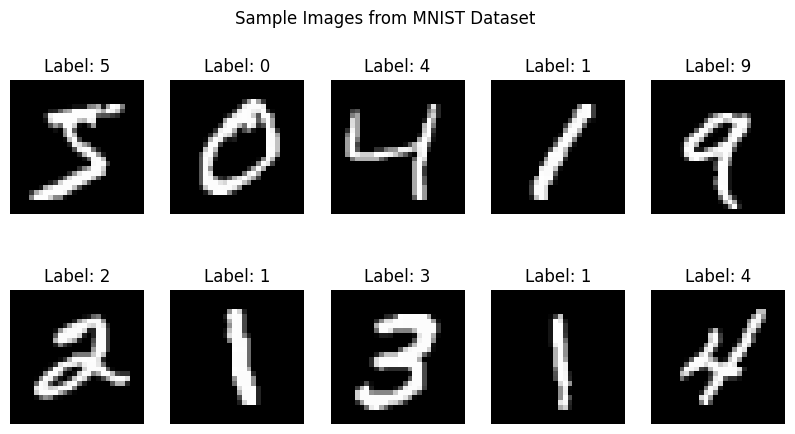

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
 822/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 31ms/step - accuracy: 0.8386 - loss: 0.5340

KeyboardInterrupt: 

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Step 1: Load MNIST Dataset
# -----------------------------
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape:", x_test.shape)

# -----------------------------
# Step 2: Display Sample Images
# -----------------------------
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")

plt.suptitle("Sample Images from MNIST Dataset")
plt.show()

# -----------------------------
# Step 3: Preprocess the Data
# -----------------------------
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape((-1,28,28,1))
x_test = x_test.reshape((-1,28,28,1))

# -----------------------------
# Step 4: Build CNN Model
# -----------------------------
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

# -----------------------------
# Step 5: Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

# -----------------------------
# Step 6: Train the Model
# -----------------------------
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)

# -----------------------------
# Step 7: Evaluate Model
# -----------------------------
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# -----------------------------
# Step 8: Predict Test Images
# -----------------------------
predictions = model.predict(x_test)

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    predicted_label = np.argmax(predictions[i])

    plt.title(f"Pred: {predicted_label}\nActual: {y_test[i]}")
    plt.axis("off")

plt.suptitle("CNN Predictions on Test Images")
plt.show()